In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import copy
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, normalize
import scipy.cluster.hierarchy as shc
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from tqdm import tqdm
import torch
from torch import nn
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorboardX import SummaryWriter
import os
import time
from torcheval.metrics import R2Score
from sklearn.metrics import r2_score
import shap
import pickle
from sklearn.linear_model import LinearRegression

%matplotlib inline
pd.set_option('display.max_columns', None)

In [4]:
deep_res_path = 'results/factor2/'
lr_res_path = 'results/linear_factor1/'

In [18]:
with open(os.path.join(deep_res_path, '1_1.pkl'), 'rb') as f:
    deep_factor_0_dict = pickle.load(f)

corr_max_idx = np.argmax(deep_factor_0_dict['alternative']['corr'])
corr_max = deep_factor_0_dict['alternative']['corr'][corr_max_idx]
r2_max = deep_factor_0_dict['alternative']['r2'][corr_max_idx]

corr_max, r2_max

(0.9994139543196976, 0.9982378644763451)

In [20]:
with open(os.path.join(lr_res_path, '0_0.pkl'), 'rb') as f:
    lr_factor_0_dict = pickle.load(f)

corr_max_idx = np.argmax(lr_factor_0_dict['alternative']['corr'])
corr_max = lr_factor_0_dict['alternative']['corr'][corr_max_idx]
r2_max = lr_factor_0_dict['alternative']['r2'][corr_max_idx]

corr_max, r2_max

(0.7766192175660651, 0.447723907606313)

In [31]:
names = ['0_0', '1_1', '2_2', '3_3', '4_4']

res_dict = dict(factor=list(), model_type=list(), corr_value=list(), r2_value=list(), loss_value=list())
for i, name in enumerate(names):
    
    with open(os.path.join(deep_res_path, name + '.pkl'), 'rb') as f:
        deep_factor_0_dict = pickle.load(f)

    corr_max_idx = np.argmax(deep_factor_0_dict['alternative']['corr'])
    corr_max = deep_factor_0_dict['alternative']['corr'][corr_max_idx]
    r2_max = deep_factor_0_dict['alternative']['r2'][corr_max_idx]
    loss_min = deep_factor_0_dict['alternative']['loss'][corr_max_idx]
    
    res_dict['factor'].append('factor_' + str(i))
    res_dict['model_type'].append('mlp')
    res_dict['corr_value'].append(corr_max)
    res_dict['r2_value'].append(r2_max)
    res_dict['loss_value'].append(loss_min)
    

    with open(os.path.join(lr_res_path, name + '.pkl'), 'rb') as f:
        lr_factor_0_dict = pickle.load(f)

    corr_max_idx = np.argmax(lr_factor_0_dict['alternative']['corr'])
    corr_max = lr_factor_0_dict['alternative']['corr'][corr_max_idx]
    r2_max = lr_factor_0_dict['alternative']['r2'][corr_max_idx]
    loss_min = lr_factor_0_dict['alternative']['loss'][corr_max_idx]
    
    res_dict['factor'].append('factor_' + str(i))
    res_dict['model_type'].append('linear_regression')
    res_dict['corr_value'].append(corr_max)
    res_dict['r2_value'].append(r2_max)
    res_dict['loss_value'].append(loss_min)

    
df = pd.DataFrame(res_dict)
# res_dict

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead


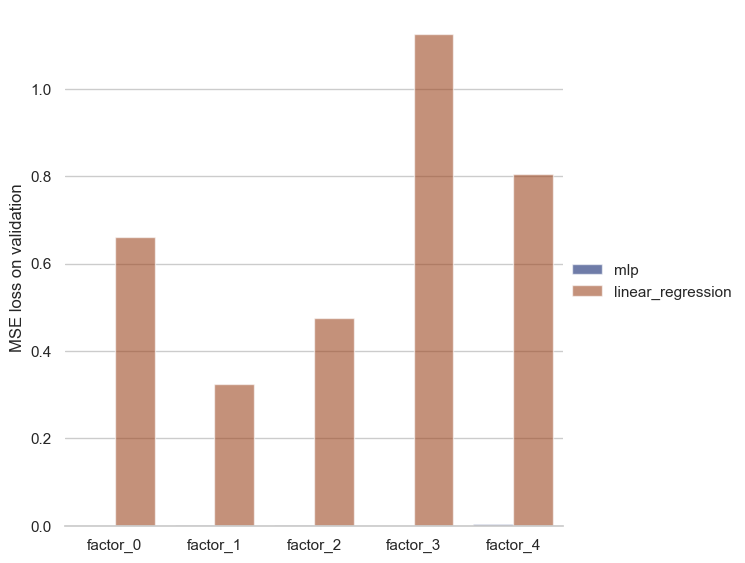

In [48]:
import seaborn as sns
sns.set_theme(style="whitegrid")


# Draw a nested barplot by species and sex
g = sns.catplot(
    data=df, kind="bar",
    x="factor", y="loss_value", hue="model_type",
    errorbar="sd", palette="dark", alpha=.6, height=6
)
g.despine(left=True)
g.set_axis_labels("", "MSE loss on validation")
g.legend.set_title("")

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead


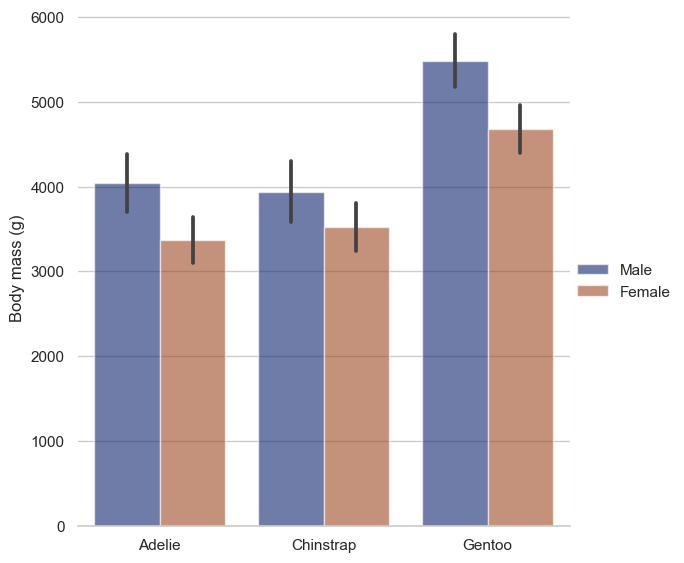

In [22]:
import seaborn as sns
sns.set_theme(style="whitegrid")

penguins = sns.load_dataset("penguins")

# Draw a nested barplot by species and sex
g = sns.catplot(
    data=penguins, kind="bar",
    x="species", y="body_mass_g", hue="sex",
    errorbar="sd", palette="dark", alpha=.6, height=6
)
g.despine(left=True)
g.set_axis_labels("", "Body mass (g)")
g.legend.set_title("")

In [23]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female
